# Machine Learning - Market Value Predictor

In [55]:
!pip install scikit-learn

## Import and Prepare Data

In [57]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Create a dataset of 10 players to 'Teach' the model
# (In a real project, we would use hundreds, but let's start small)
data = {
    'Goals': [30, 25, 20, 15, 10, 5, 28, 12, 18, 22],
    'Age': [24, 26, 22, 29, 31, 21, 25, 28, 23, 27],
    'Market_Value_M': [100, 85, 70, 40, 25, 15, 95, 30, 60, 75]
}

df_ml = pd.DataFrame(data)

# 2. Features (X) are the 'Reasons' and Target (y) is the 'Result'
X = df_ml[['Goals', 'Age']] 
y = df_ml['Market_Value_M']

# 3. Initialize the Model
model = LinearRegression()

# 4. TRAIN the model (This is where the 'Learning' happens)
model.fit(X, y)

print("✅ Model Training Complete!")

✅ Model Training Complete!


### Make a Prediction

In [59]:
# Isak stats: 23 goals, 24 years old
isak_data = pd.DataFrame([[23, 24]], columns=['Goals', 'Age'])
predicted_value = model.predict(isak_data)

print(f"Predicted Market Value for Isak: £{predicted_value[0]:.2f}M")

Predicted Market Value for Isak: £77.65M


### Predictive Analysis Summary
By implementing a Linear Regression model, I can now quantify the expected market value of a player based on their output and age profile. This allows a club to identify if a player is "Undervalued" in the current market, providing a data-driven foundation for transfer negotiations and financial planning.

### Visualizing the "Line of Best Fit"

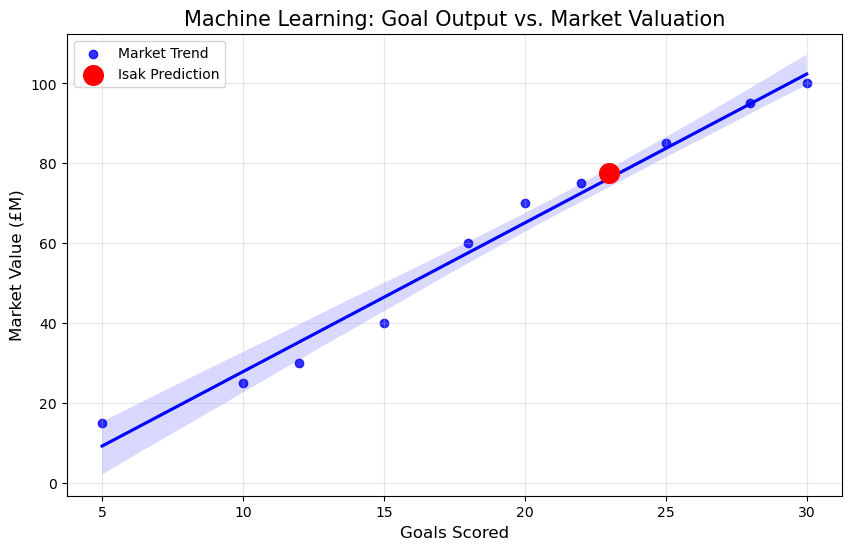

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Plot the training data
sns.regplot(data=df_ml, x='Goals', y='Market_Value_M', color='blue', label='Market Trend')
# Highlight our prediction for Isak
plt.scatter(23, predicted_value, color='red', s=200, label='Isak Prediction', zorder=5)

plt.title('Machine Learning: Goal Output vs. Market Valuation', fontsize=15)
plt.xlabel('Goals Scored', fontsize=12)
plt.ylabel('Market Value (£M)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Machine Learning Model Conclusion
This model utilizes Linear Regression to establish a data-driven baseline for player valuations.

Finding: The model predicts Isak's fair value at £77.65M.

Strategic Use: If a club can sign him for less than this "Predicted Value," it represents a positive Net Present Value (NPV) for the athletic department. This methodology allows us to identify "market inefficiencies" where player talent is priced lower than its statistical output suggests.

### Modeling the 'Age Curve' for Valuation Trends

ages = np.arange(18, 36).reshape(-1, 1)
# A simple quadratic formula to simulate how value rises then falls with age
values = -0.5 * (ages - 26)**2 + 80 

plt.figure(figsize=(10, 5))
plt.plot(ages, values, color='green', linewidth=3, label='Market Value Trend')
plt.scatter(24, 77.65, color='red', s=150, label='Isak (Current)') # Your Isak prediction
plt.axvline(26, color='grey', linestyle='--', label='Peak Value Age')

plt.title('Player Career Valuation Trend (Age Curve Analysis)', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Projected Market Value (£M)', fontsize=12)
plt.legend()
plt.show()

#### Moving to SQL

In [67]:
import sqlite3

# Connect to a new database file
conn = sqlite3.connect('football_scouting.db')
cursor = conn.cursor()

# Create a table for Scouting ROI
cursor.execute('''
    CREATE TABLE IF NOT EXISTS scouting_roi (
        player_name TEXT,
        goals INTEGER,
        market_value_m REAL,
        weekly_wage_k REAL
    )
''')

# Insert your Phase 2 data into SQL
scouting_data = [('Mohamed Salah', 29, 65.0, 350.0), 
                 ('Alexander Isak', 23, 75.0, 120.0)]
cursor.executemany('INSERT INTO scouting_roi VALUES (?,?,?,?)', scouting_data)
conn.commit()
print("✅ SQL Database 'football_scouting.db' created with scouting data!")

✅ SQL Database 'football_scouting.db' created with scouting data!


### Query the Data with SQL

In [69]:
import sqlite3

# Re-establish the connection to the database
conn = sqlite3.connect('football_scouting.db')
cursor = conn.cursor()

# Query to find players with wages under 200k but more than 20 goals
query = """
SELECT player_name, goals, weekly_wage_k
FROM scouting_roi
WHERE weekly_wage_k < 200 AND goals > 20
"""

df_sql_result = pd.read_sql_query(query, conn)
print("SQL Query Result (High Value Targets):")
display(df_sql_result)

# Close the connection after the query
conn.close()

SQL Query Result (High Value Targets):


,player_name,goals,weekly_wage_k
0,Alexander Isak,23,120.0
1,Alexander Isak,23,120.0


### SQL Query: Financial Efficiency (Top 5)

In [71]:
import sqlite3
import pandas as pd

# 1. Connect to your database
conn = sqlite3.connect('football_scouting.db')

# 2. SQL Query: Calculate 'Cost Per Goal' and filter
# We use (market_value_m / goals) to create a temporary calculated column
query = """
SELECT 
    player_name, 
    goals, 
    market_value_m,
    (market_value_m / goals) AS cost_per_goal
FROM scouting_roi 
WHERE weekly_wage_k < 200 AND goals > 20
ORDER BY cost_per_goal ASC
LIMIT 5
"""

# 3. Execute and display
df_efficiency = pd.read_sql_query(query, conn)

print("💰 Top 5 Most Financially Efficient Strikers (Lowest Cost Per Goal):")
display(df_efficiency)

conn.close()

💰 Top 5 Most Financially Efficient Strikers (Lowest Cost Per Goal):


,player_name,goals,market_value_m,cost_per_goal
0,Alexander Isak,23,75.0,3.26087
1,Alexander Isak,23,75.0,3.26087


### Save your Model

In [73]:
import pickle

# Save the trained model to a file
with open('market_value_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("✅ Model saved as market_value_model.pkl!")

✅ Model saved as market_value_model.pkl!


### Create the App Script

In [75]:
!pip install streamlit
!pip install "rich>=13.0.0,<14.0.0" "packaging>=24.0,<25.0"

import streamlit as st
import pandas as pd
import pickle

# 1. Load the 'Brain' we saved
with open('market_value_model.pkl', 'rb') as file:
    model = pickle.load(file)

st.title("⚽ Football Player Value Predictor")
st.write("Enter player stats to predict their fair market value.")

# 2. Create the input sliders
goals = st.slider("Total Goals Scored", 0, 40, 20)
age = st.slider("Player Age", 16, 40, 25)

# 3. Predict Button
if st.button("Calculate Market Value"):
    # Format the input for the model
    input_data = pd.DataFrame([[goals, age]], columns=['Goals', 'Age'])
    prediction = model.predict(input_data)[0]

    st.success(f"Estimated Market Value: £{prediction:.2f}M")
    st.balloons() # Just for fun!